(<matplotlib.image.AxesImage at 0x1384c274d88>, Text(0.5, 1.0, 'Changed'))

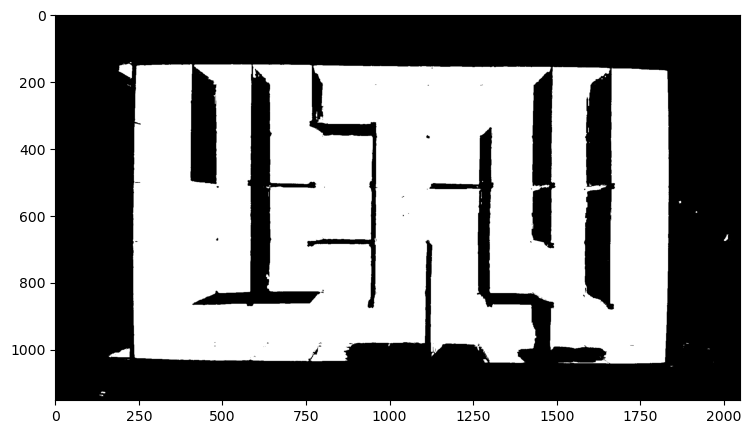

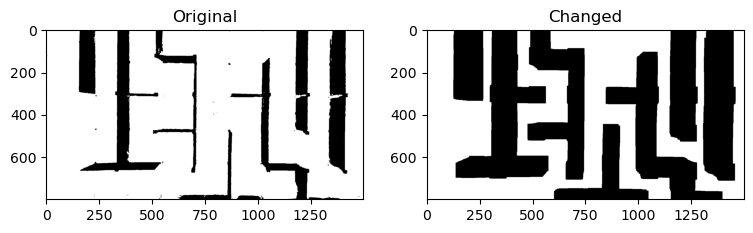

In [1]:
# chatGPT was used in some sections and for code cleanup
# OpenAI. (2024). ChatGPT (Aug 3 version) [Large language model].
import cv2
import numpy as np
import random
import math
from matplotlib import pyplot as plt

random.seed(42)
%matplotlib inline

IMAGE_FILE = "maze.jpg"
thresh = 128
maxval = 255


img_maze = cv2.imread(IMAGE_FILE)
img_hsv = cv2.cvtColor(img_maze, cv2.COLOR_BGR2HSV)

hsv_mask = cv2.inRange(img_hsv, (4,38,101), (27,255, 255))


_, threshed = cv2.threshold(hsv_mask, thresh, maxval, cv2.THRESH_BINARY)
threshed_3_channel = cv2.cvtColor(threshed, cv2.COLOR_GRAY2BGR)

plt.figure(figsize = (9,5))
plt.imshow(threshed_3_channel)


img = cv2.cvtColor(threshed[200:1000, 250:1750], cv2.COLOR_GRAY2BGR)
kernel = np.ones((3,3), np.uint8)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(100, 2))

# Dilation
kernel_size = 4
kernel = np.ones((kernel_size, kernel_size), np.uint8)
imgNew = cv2.dilate(img, kernel, iterations = 2)


# Erosion
kernel_size = 15
kernel = np.ones((kernel_size, kernel_size), np.uint8)
imgNew = cv2.erode(imgNew, kernel, iterations = 5)


fig, (ax1, ax2) = plt.subplots(figsize = (9, 5), ncols = 2)
ax1.imshow(img, cmap = 'gray'), ax1.set_title("Original")
ax2.imshow(imgNew, cmap='gray'), ax2.set_title("Changed")


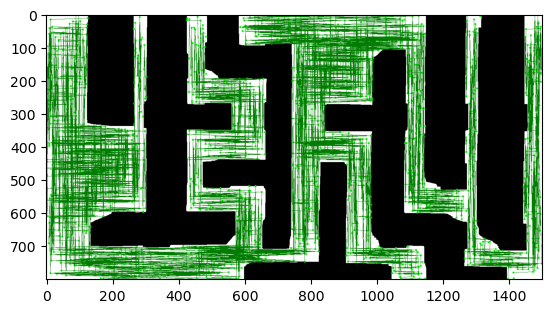

In [2]:
import random
iterations = 2000
k_connections = 7
max_connection_range = 200

class Node:
    def __init__(self, node_id, x, y):
        self.id = node_id
        self.x = x
        self.y = y
    
    def get_point(self):
        return (self.x,self.y)
    
    def get_ID(self):
        return self.id

class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}
        
    def add_node(self, node_id, x, y):
        if node_id not in self.nodes:
            self.nodes[node_id] = Node(node_id, x, y)
            self.edges[node_id] = {}

    def add_edge(self, node_id1, node_id2, weight):
        if node_id1 in self.nodes and node_id2 in self.nodes:
            self.edges[node_id1][node_id2] = weight
            self.edges[node_id2][node_id1] = weight

    def remove_edge(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            del self.edges[node_id1][node_id2]
            del self.edges[node_id2][node_id1]
    
    def get_nodes(self):
        return self.nodes
    
    def get_edge_weight(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            return self.edges[node_id1][node_id2]

        
# This is a useful function which you may choose to impliment and use 
# It looks through the image to see if the path is clear between one cooridnate to the next
# Returns True or False 
def path_clear(image, x1, y1, x2, y2):
    num_points = max(abs(x2 - x1), abs(y2 - y1)) 
    for i in range(num_points + 1):
        x = int(x1 + i * (x2 - x1) / num_points)
        y = int(y1 + i * (y2 - y1) / num_points)
        pixel = image[x, y]
        if (pixel[0] == 255 and pixel[1] == 0 and pixel[2] == 0) or np.all(pixel == [0, 0, 0]):
            return False
    return True


def find_closest_nodes(graph, target_x, target_y, n,range):

    distances = []
    nodes_dict = graph.get_nodes()
    for node_id in nodes_dict:
        x, y = nodes_dict[node_id].get_point()
        distance = np.sqrt((x - target_x) ** 2 + (y - target_y) ** 2)
        if (target_x - x == 0):
            if distance <= range and distance > 0:
                distances.append((distance, node_id))
        else:
            m = (target_y - y)/(target_x - x)
            if distance <= range and distance > 0 and (abs(m) < 0.05 or abs(m) > 30):
                distances.append((distance, node_id))

#         if distance <= range and distance > 0:
#             distances.append((distance, node_id))

    # chatGPT code
    # Sort the distance list by distance
    sorted_distances = sorted(distances, key=lambda x: x[0]) 
    return [node_id for distance, node_id in sorted_distances]

# Task 4.1 (3 marks): PRM
# NOTE: The iteration only increases when a valid node is placed on the map. If the node is invalid, the program should continue without incrementing the iteration count. 

prm_image = imgNew.copy()
prm_graph = Graph()

i = 0
node_id = 0
nodes_dict = prm_graph.get_nodes()
iterations
while i < iterations:
    y = random.randint(0, prm_image.shape[0] - 1)
    x = random.randint(0, prm_image.shape[1] - 1)
    pixel = prm_image[y, x]
        
    if not ((pixel[0] == 255 and pixel[1] == 0 and pixel[2] == 0) or (pixel[0] == 0 and pixel[1] == 0 and pixel[2] == 0)):
        prm_graph.add_node(node_id, x, y)
        neighbors = find_closest_nodes(prm_graph, x, y, k_connections, max_connection_range)
        connection_count = 0

        for neighbor_id in neighbors:
            is_line_free = False
            x1, y1 = nodes_dict[node_id].get_point()
            x2, y2 = nodes_dict[neighbor_id].get_point()
            
            # Code by chatGPT
            # Description: Incrementally check line
            # Date: Aug 1 2024
            line_points = np.linspace(0, 1, int(np.hypot(x2 - x1, y2 - y1)))
            
            is_line_free = True
            for t in line_points:
                x = int(x1 * (1 - t) + x2 * t)
                y = int(y1 * (1 - t) + y2 * t)
                pixel = prm_image[y, x]
                if (pixel[0] == 0 and pixel[1] == 0 and pixel[2] == 0) or (pixel[0] == 255 and pixel[1] == 0 and pixel[2] == 0):
                    is_line_free = False
                    break
            
            if is_line_free:     
                nodes_dict = prm_graph.get_nodes()
                x1, y1 = nodes_dict[node_id].get_point()
                x2, y2 = nodes_dict[neighbor_id].get_point()
                weight = np.sqrt((x2 - x1) ** 2 + (y2 - y1) **  2)
                prm_graph.add_edge(node_id, neighbor_id, weight)
                cv2.line(prm_image, (x, y), prm_graph.nodes[neighbor_id].get_point(), (0, 125, 0), 1)
                connection_count += 1

            if connection_count == k_connections:
                break


        node_id += 1
        i += 1

# Draw nodes
for node in prm_graph.get_nodes().values():
    cv2.circle(prm_image, node.get_point(), 3, (0, 255, 0), -1)

# Draw edges
nodes = prm_graph.get_nodes()
for node_id1 in nodes:
    for node_id2 in nodes:
        if prm_graph.get_edge_weight(node_id1, node_id2) != None:
            x1, y1 = nodes[node_id1].get_point()
            x2, y2 = nodes[node_id2].get_point()
            cv2.line(prm_image, (x1, y1), (x2, y2), (0, 125, 0), 1)

# Display resulting image
plt.imshow(prm_image)
plt.show()


In [3]:
def is_free(pixel):
    flag = (pixel[0] == 255 and pixel[1] == 0 and pixel[2] == 0) or (pixel[0] == 0 and pixel[1] == 0 and pixel[2] == 0)
    return not flag

def euclidean_distance(graph, node_id1, node_id2):
    x1, y1 = graph.nodes[node_id1].get_point()
    x2, y2 = graph.nodes[node_id2].get_point()
    return np.sqrt((x2 - x1) ** 2 + (y2 - y1) **  2)

def is_line_free(image, graph, node_id1, node_id2):
    x1, y1 = graph.nodes[node_id1].get_point()
    x2, y2 = graph.nodes[node_id2].get_point()
        
    # Code by chatGPT
    # Description: Incrementally check the line along 2 coordinates
    # Date: July 30 2024
    line_iter = np.linspace(0, 1, int(np.sqrt((x2 - x1)**2 + (y2 - y1)**2)))
    for t in line_iter:    
        x = int(x1 * (1 - t) + x2 * t)
        y = int(y1 * (1 - t) + y2 * t)  
        if (image[y, x][0] == 0 and image[y, x][1] == 0 and image[y, x][2] == 0) or (image[y, x][0] == 255 and image[y, x][1] == 0 and image[y, x][2] == 0):  # Black or red
            return False
        
    return True

def dijkstra(graph, start_id, end_id):
    dist = {node: float('inf') for node in graph.nodes}
    pred = {node: None for node in graph.nodes}
    dist[start_id] = 0
    
    unvisited_nodes = set(graph.nodes)
    while unvisited_nodes:
        min_node = min(unvisited_nodes, key=lambda node: dist[node])
        unvisited_nodes.remove(min_node)
        for neighbor, weight in graph.edges[min_node].items():
            new_dist = dist[min_node] + weight
            if new_dist < dist[neighbor]:
                dist[neighbor] = new_dist
                pred[neighbor] = min_node
    
    path = []
    current = end_id
    while current is not None:
        path.append(current)
        current = pred[current]
    path.reverse()
    total_cost = dist[end_id]

    return (path, total_cost)

1485 100
Path: [-1, 1938, 576, 774, 359, 985, 673, 162, 1080, 1700, 750, 1981, 445, 1433, 1311, 660, 1147, 927, 1573, 1485, 1892, 1250, 546, 1205, 1780, 1427, 1409, 1850, 466, 212, 262, 761, -2], Cost: 3807.7442582416415


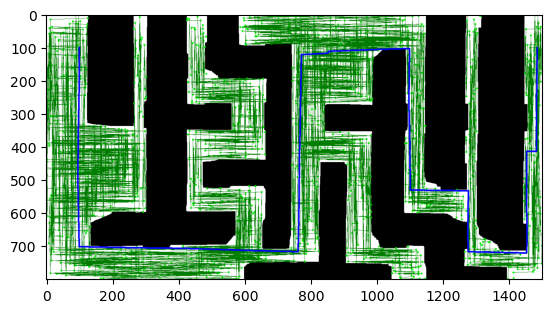

['f', 'f', 'f', 'f', 'l', 'f', 'f', 'f', 'f', 'l', 'f', 'f', 'f', 'f', 'r', 'f', 'f', 'r', 'f', 'f', 'f', 'l', 'f', 'r', 'f', 'l', 'f', 'l', 'f', 'f', 'f', 'f']


In [5]:
start_location = [100, 100]
goal_location = [1485, 100]
x1, y1 = start_location 
x2, y2 = goal_location 
print(x2, y2)
prm_graph.add_node(-1, x1, y1) # start node
prm_graph.add_node(-2, x2, y2) # end node

dictionary = prm_graph.get_nodes()
for node_id in [-1, -2]:
    x, y = dictionary[node_id].get_point()
    neighbours = find_closest_nodes(prm_graph, x, y, k_connections, max_connection_range)
#     cv2.putText(prm_image, str(node_id), (x, y), font, 0.5, color, 1, cv2.LINE_AA)
    j = 0
    for neighbour_id in neighbours:
        if is_line_free(prm_image, prm_graph, node_id, neighbour_id):
            prm_graph.add_edge(node_id, neighbour_id, euclidean_distance(prm_graph, node_id, neighbour_id))
            cv2.line(prm_image, (x, y), prm_graph.nodes[neighbour_id].get_point(), (0, 125, 0), 1)
            j += 1
        if j == k_connections:
            break

path, cost = dijkstra(prm_graph, -1, -2)
h, w, _ = prm_image.shape
rows, cols = [5, 9]
dy, dx = h / rows, w / cols

x_array = []
y_array = []

for xx in np.linspace(start=dx, stop=w-dx, num=cols-1):
        xx = int(round(xx))
        x_array.append(xx)

# draw horizontal lines
for yy in np.linspace(start=dy, stop=h-dy, num=rows-1):
    yy = int(round(yy))
    y_array.append(yy)

path_commands = []

for i in range(len(path) - 1):
    node_id1 = path[i]
    node_id2 = path[i + 1]
    
    x1, y1 = prm_graph.nodes[node_id1].get_point()
    x2, y2 = prm_graph.nodes[node_id2].get_point()
    
    for i in y_array:
        if ((y2 > i and y1 < i) or (y2 < i and y1 > i)):
            if (y2 > y1):
                path_commands.append("D")
            elif (y2 < y1):
                path_commands.append("U")
                
    for i in x_array:
        if ((x2 > i and x1 < i) or (x2 < i and x1 > i)):
            if (x2 > x1):
                path_commands.append("R")
            elif (x2 < x1):
                path_commands.append("L")
                
    cv2.line(prm_image, (x1, y1), (x2, y2), (0, 0, 255), 3)

# Display resulting image
print(f"Path: {path}, Cost: {cost}")
plt.imshow(prm_image)
plt.show()

robot_commands = ["f"]
direction = "south"
counter = 0
while counter < len(path_commands):
    if not (counter == len(path_commands) - 1):
        if (path_commands[counter] == path_commands[counter+1]):
            robot_commands.append("f")
        else:
            if (path_commands[counter+1] == "R"):
                if (direction == "south"):
                    robot_commands.append("l")
                    robot_commands.append("f")
                    direction = "east"
                elif (direction == "north"):
                    robot_commands.append("r")
                    robot_commands.append("f")
                    direction = "east"
                elif (direction == "west"):
                    robot_commands.append("r")
                    robot_commands.append("r")
                    robot_commands.append("f")
                    direction = "east"
            if (path_commands[counter+1] == "L"):
                if (direction == "south"):
                    robot_commands.append("r")
                    robot_commands.append("f")
                    direction = "west"
                elif (direction == "north"):
                    robot_commands.append("l")
                    robot_commands.append("f")
                    direction = "west"
                elif (direction == "east"):
                    robot_commands.append("l")
                    robot_commands.append("l")
                    robot_commands.append("f")
                    direction = "west"
            if (path_commands[counter+1] == "U"):
                if (direction == "south"):
                    robot_commands.append("r")
                    robot_commands.append("r")
                    robot_commands.append("f")
                    direction = "north"
                elif (direction == "west"):
                    robot_commands.append("r")
                    robot_commands.append("f")
                    direction = "north"
                elif (direction == "east"):
                    robot_commands.append("l")
                    robot_commands.append("f")
                    direction = "north"
            if (path_commands[counter+1] == "D"):
                if (direction == "north"):
                    robot_commands.append("r")
                    robot_commands.append("r")
                    robot_commands.append("f")
                    direction = "south"
                elif (direction == "west"):
                    robot_commands.append("l")
                    robot_commands.append("f")
                    direction = "south"
                elif (direction == "east"):
                    robot_commands.append("r")
                    robot_commands.append("f")
                    direction = "south"
    counter += 1
    
print(robot_commands)